# Determine sky position of source using a Bayesian method

- Amplitude measurement is good.
- Phase measurement is jittery --> add some jitter to phase in compute response.

What amount of phase accuracy do we need for a decent skymap?

## Read in fits data

In [1]:
import numpy as np

In [2]:
import numpy as np

def single_band_network_response_analyzer(fits, f_gw1):
    
    # 1. Reconstruct Complex Signals for Band 1
    fit_S = []
    for fit in fits:
        # Create complex signal S = A * e^(i*phi)
        fit_S.append(fit['amplitude'] * np.exp(1j * fit['phase']))
    
    fit_S = np.array(fit_S)

    # 2. Extract Errors
    phases_err = []
    rel_amp_err = []

    for fit in fits:
        phases_err.append(fit['phase_err'])
        # Added a check to avoid division by zero
        amp = fit['amplitude'] if fit['amplitude'] != 0 else 1.0e-20
        rel_amp_err.append(np.abs(fit['amplitude_err'] / amp))

    phases_err = np.array(phases_err)
    rel_amp_err = np.array(rel_amp_err)

    # 3. Calculate Normalized Antenna Response
    # Normalizes all signals relative to the first detector (fit_S[0])
    # The term (np.exp(-1j*2*np.pi*f_gw1)) applies a constant phase shift 
    antenna_response = fit_S / fit_S[0] / np.exp(-1j * 2 * np.pi * f_gw1)
    
    # 4. Calculate Final Outputs
    antenna_response_amp = np.abs(antenna_response)
    
    # Propagate Error: New Amp * Original Relative Error
    antenna_response_amp_err = antenna_response_amp * rel_amp_err
    
    antenna_response_phase = np.angle(antenna_response)
    antenna_response_phase_err = phases_err
    
    return (antenna_response_amp, antenna_response_amp_err, antenna_response_phase, antenna_response_phase_err)

In [3]:
import json

In [4]:
json_file_name = "data_3.json"

In [5]:
with open(json_file_name, 'r') as file:
    data = json.load(file)

FileNotFoundError: [Errno 2] No such file or directory: 'data_3.json'

In [6]:
data.keys()

NameError: name 'data' is not defined

In [7]:
data['fits1']

NameError: name 'data' is not defined

In [8]:
##Measurement Cycles
f_gw1 = 1/100 ##Keep this in the 10s of mHz 

In [9]:
antenna_response_amp, antenna_response_amp_err, antenna_response_phase, antenna_response_phase_err  = single_band_network_response_analyzer(data['fits1'],f_gw1)

NameError: name 'data' is not defined

In [10]:
antenna_response_amp, antenna_response_amp_err, antenna_response_phase, antenna_response_phase_err

NameError: name 'antenna_response_amp' is not defined

# BAYESIAN SKY LOC INFERENCE

In [12]:
import bilby
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.stats import norm
from bilby.core.utils import random

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

f0 = 429e12
h_const = lal.H_SI
G = lal.G_SI
c = lal.C_SI
M0 = lal.MSUN_SI


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.9/site-pack

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [ ]:

def normalize_with_errors(z, rel_amp_err, phase_err):
    """
    Parameters
    ----------
    z : array_like (complex)
        Complex numbers z_k
    rel_amp_err : array_like (float)
        Relative amplitude errors (sigma_Ak / Ak)
    phase_err : array_like (float)
        Absolute phase errors (radians)

    Returns
    -------
    r : complex ndarray
        Normalized complex list z_k / z_0
    sigma_re : ndarray
        Error on real part of normalized response
    sigma_im : ndarray
        Error on imaginary part of normalized response
    sigma_A0 : float
        Absolute error on overall magnitude |z_0|
    """

    z = np.asarray(z)
    rel_amp_err = np.asarray(rel_amp_err)
    phase_err = np.asarray(phase_err)

    A = np.abs(z)
    phi = np.angle(z)

    # Normalization reference
    A0 = A[0]
    phi0 = phi[0]

    # Overall magnitude error
    sigma_A0 = rel_amp_err[0] * A0

    # Relative amplitudes and phase differences
    alpha = A / A0
    delta_phi = phi - phi0

    # Relative amplitude errors (ratio propagation)
    sigma_alpha = alpha * np.sqrt(rel_amp_err**2 + rel_amp_err[0]**2)

    # Phase difference errors
    sigma_delta_phi = np.sqrt(phase_err**2 + phase_err[0]**2)

    # Normalized complex response
    r = alpha * np.exp(1j * delta_phi)

    # Real and imaginary parts
    cos = np.cos(delta_phi)
    sin = np.sin(delta_phi)

    # Error propagation
    sigma_re = np.sqrt(
        (cos**2) * sigma_alpha**2 +
        (alpha**2) * (sin**2) * sigma_delta_phi**2
    )

    sigma_im = np.sqrt(
        (sin**2) * sigma_alpha**2 +
        (alpha**2) * (cos**2) * sigma_delta_phi**2
    )

    return r, A0, sigma_re, sigma_im, sigma_A0

# Detector Network

In [64]:
N_detectors = 3

theta_1 = 0
theta_2 = np.pi/3
theta_3 = np.pi/6

r = 1.46e11 #metres

detector_positions = np.array([[r*np.cos(theta_1),r*np.sin(theta_1),0],[r*np.cos(theta_2),r*np.sin(theta_2),0],[r*np.cos(theta_3),r*np.sin(theta_3),0]])
detector_arms = np.array([[np.sin(theta_1),np.cos(theta_1),0],[np.sin(theta_2),np.cos(theta_2),0],[np.sin(theta_3),np.cos(theta_3),0]])
arm_lengths = np.array([1e10,1e10,1e10])

# Measurement frequency and Chirp Mass

In [65]:
f_gw=0.01
Mc = 500*M0

# GW MODEL

In [66]:
def compute_fd_complex_response(f_gw, ra, dec, A, iota, psi):
    arm_lengths = np.array(arm_lengths)
    # GW propagation vector
    theta, phi = bilby.core.utils.conversion.ra_dec_to_theta_phi(ra, dec, 0)
    k = -np.array([
        np.sin(theta) * np.cos(phi_sky),
        np.sin(theta) * np.sin(phi_sky),
        np.cos(theta)
    ])
    # 1. Amplitudes
    A_plus = A * (1+np.cos(iota)**2)/2
    A_cross = A * np.cos(iota)
    
    def make_perp_basis(k):
        k = k / np.linalg.norm(k)
        if np.abs(k[2]) < 0.99:
            tmp = np.array([0,0,1])
        else:
            tmp = np.array([1,0,0])
        ex = np.cross(tmp, k)
        ex /= np.linalg.norm(ex)
        ey = np.cross(k, ex)
        return ex, ey

    ex, ey = make_perp_basis(k)

    # Polarization tensors
    e_plus = np.outer(ex, ex) - np.outer(ey, ey)
    e_cross = np.outer(ex, ey) + np.outer(ey, ex)

    # Rotate by polarization angle psi
    e_plus_rot  = e_plus * np.cos(2 * psi) + e_cross * np.sin(2 * psi)
    e_cross_rot = -e_plus * np.sin(2 * psi) + e_cross * np.cos(2 * psi)

    # --- CLOCK ANTENNA GEOMETRY ---
    # n̂ = photon propagation direction
    nk = np.einsum("di,i->d", arms, k)
    denom = 1.0 - nk

    # Geometry-only detector tensor
    D = 0.5 * np.einsum("di,dj->dij", arms, arms) / denom[:, None, None]

    # Antenna factors
    F_plus  = np.einsum("dij,ij->d", D, e_plus_rot)
    F_cross = np.einsum("dij,ij->d", D, e_cross_rot)

    # Keep original phase convention
    tau = np.dot(positions, k) / c
   
    phase_delay = 2 * np.pi * f_gw * arm_lengths * denom / c
    transfer = 1.0 - np.exp(-1j * phase_delay)
   
    # Pure antenna-pattern response (no transfer function)
    S = (F_plus * A_plus + F_cross * A_cross) * np.exp(-1j * 2 * np.pi * f_gw * tau) * transfer
    
    S_model = S/S[0]
    
    A_model = np.abs(S[0])
    
    return S_model, A_model


In [ ]:
def compute_fd_complex_response_no_amp(f_gw, ra, dec, iota, psi):
    arm_lengths = np.array(arm_lengths)
    # GW propagation vector
    theta, phi = bilby.core.utils.conversion.ra_dec_to_theta_phi(ra, dec, 0)
    k = -np.array([
        np.sin(theta) * np.cos(phi_sky),
        np.sin(theta) * np.sin(phi_sky),
        np.cos(theta)
    ])
    # 1. Amplitudes
    A = 1
    A_plus = A * (1+np.cos(iota)**2)/2
    A_cross = A * np.cos(iota)
    
    def make_perp_basis(k):
        k = k / np.linalg.norm(k)
        if np.abs(k[2]) < 0.99:
            tmp = np.array([0,0,1])
        else:
            tmp = np.array([1,0,0])
        ex = np.cross(tmp, k)
        ex /= np.linalg.norm(ex)
        ey = np.cross(k, ex)
        return ex, ey

    ex, ey = make_perp_basis(k)

    # Polarization tensors
    e_plus = np.outer(ex, ex) - np.outer(ey, ey)
    e_cross = np.outer(ex, ey) + np.outer(ey, ex)

    # Rotate by polarization angle psi
    e_plus_rot  = e_plus * np.cos(2 * psi) + e_cross * np.sin(2 * psi)
    e_cross_rot = -e_plus * np.sin(2 * psi) + e_cross * np.cos(2 * psi)

    # --- CLOCK ANTENNA GEOMETRY ---
    # n̂ = photon propagation direction
    nk = np.einsum("di,i->d", arms, k)
    denom = 1.0 - nk

    # Geometry-only detector tensor
    D = 0.5 * np.einsum("di,dj->dij", arms, arms) / denom[:, None, None]

    # Antenna factors
    F_plus  = np.einsum("dij,ij->d", D, e_plus_rot)
    F_cross = np.einsum("dij,ij->d", D, e_cross_rot)

    # Keep original phase convention
    tau = np.dot(positions, k) / c
   
    phase_delay = 2 * np.pi * f_gw * arm_lengths * denom / c
    transfer = 1.0 - np.exp(-1j * phase_delay)
   
    # Pure antenna-pattern response (no transfer function)
    S = (F_plus * A_plus + F_cross * A_cross) * np.exp(-1j * 2 * np.pi * f_gw * tau) * transfer
    
    S_model = S/S[0]
    
    A_model = np.abs(S[0])
    
    return S_model, A_model


# LIKELIHOOD CLASS

In [3]:
class GWNetworkLikelihood(bilby.likelihood.Likelihood):
    def __init__(self, data_S,data_A, error_S_re,error_S_im,error_A, model):
        # We only accept Complex Strain (S) data, NO time delay (tau) data
        self.data_S = data_S     # Complex array [Amp * exp(i*Phase)]
        self.error_S_re = error_S_re   # Error array
        self.error_S_im = error_S_im   # Error array
        self.error_A = error_A   # Error array
        self.model = model 

        super().__init__(parameters={'ra': None, 'dec': None, 
                                     'A': None, 'iota': None,
                                     'psi': None})

    def log_likelihood(self):
        try:
            S_model, A_model = self.model(f_gw, **self.parameters)
        except Exception as e:
            return -np.inf
        
        
        delta_S = self.data_S - S_model
        
        

        # Split into Real and Imaginary parts
        delta_S_re = np.real(delta_S)/1000
        delta_S_im = np.imag(delta_S)/1000
        delta_A = (self.data_A-A_model)/1000
        
        sigma_S_re = self.error_S_re**2
        sigma_S_im = self.error_S_im**2
        sigma_A = self.error_A**2
        
        # Calculate chi-squared for Real and Imaginary parts
        ln_L_S_re = -0.5 * np.sum((delta_S_re**2 / sigma_S_re) + np.log(2 * np.pi * sigma_S_re))
        ln_L_S_im = -0.5 * np.sum((delta_S_im**2 / sigma_S_im) + np.log(2 * np.pi * sigma_S_im))
        ln_L_A = -0.5 * np.sum((delta_A**2 / sigma_A) + np.log(2 * np.pi * sigma_A))
        
        # Total Likelihood is just the Strain part
        return ln_L_S_re + ln_L_S_im + ln_L_A

NameError: name 'bilby' is not defined

In [ ]:
class GWNetworkLikelihood_no_amp(bilby.likelihood.Likelihood):
    def __init__(self, data_S, error_S_re,error_S_im, model):
        # We only accept Complex Strain (S) data, NO time delay (tau) data
        self.data_S = data_S     # Complex array [Amp * exp(i*Phase)]
        self.error_S_re = error_S_re   # Error array
        self.error_S_im = error_S_im   # Error array
        self.model = model 

        super().__init__(parameters={'ra': None, 'dec': None, 
                                     'A': None, 'iota': None,
                                     'psi': None})

    def log_likelihood(self):
        try:
            S_model, A_model = self.model(f_gw, **self.parameters)
        except Exception as e:
            return -np.inf
        
        
        delta_S = self.data_S - S_model
        
        

        # Split into Real and Imaginary parts
        delta_S_re = np.real(delta_S)/1000
        delta_S_im = np.imag(delta_S)/1000
        
        sigma_S_re = self.error_S_re**2
        sigma_S_im = self.error_S_im**2

        
        # Calculate chi-squared for Real and Imaginary parts
        ln_L_S_re = -0.5 * np.sum((delta_S_re**2 / sigma_S_re) + np.log(2 * np.pi * sigma_S_re))
        ln_L_S_im = -0.5 * np.sum((delta_S_im**2 / sigma_S_im) + np.log(2 * np.pi * sigma_S_im))

        # Total Likelihood is just the Strain part
        return ln_L_S_re + ln_L_S_im 

# SETUP

In [4]:
label = "gw_localization"
outdir = "outdir_ra_dec_A_iota_psi_1003"
bilby.utils.check_directory_exists_and_if_not_mkdir(outdir)
random.seed(123)
rng = np.random.default_rng(123) # Use a modern random number generator

NameError: name 'bilby' is not defined

# INJECTION

In [69]:
def get_dL(Mc, A, f_gw):
    "get dL in Mpc; A from https://arxiv.org/pdf/2507.10597"
    return f_gw**(-7/6) * (1./A) * (5./(24 * np.pi ** (4/3))) * ((G * Mc*2e30) **(5./6.))/c**(3./2.) * 3.2407792896664e-26

In [70]:
get_dL(1000, 1e-20, 0.01)

113.72093774039392

In [71]:
injection_parameters = dict(
    ra=0.5,                 # Right Ascension (rad)
    dec=0.7,                # Declination (rad)
    psi=np.pi/3,               # Polarization angle (rad)
    A  = 1e-20,
    iota = np.pi/3
)
#time_delay_ref=0.0  # Reference time delay

# GENERATE DATA

In [72]:
# Generate NEW clean data using the NO-DELAY model
S_true, _ = compute_complex_response(f_gw, **injection_parameters)

# Add noise
sigma_S = np.ones(N_detectors) * 1e-22 
data_S = S_true + rng.normal(0, sigma_S, N_detectors) + 1j * rng.normal(0, sigma_S, N_detectors)

print("Data Generated.")


Data Generated.


# Instantiate Likelihood

In [73]:
# Re-initialize likelihood with new data
likelihood = GWNetworkLikelihood(
    data_S=data_S, 
    error_S=sigma_S, 
    model=compute_complex_response
)

# Test at Injection
likelihood.parameters.update(injection_parameters)
print(f"Log Likelihood at Injection: {likelihood.log_likelihood()}")

Log Likelihood at Injection: 296.4326614183899


# PRIORS

In [74]:
# Define Priors (We want to sample the full sky)
priors = bilby.core.prior.PriorDict()
priors["dec"] = bilby.core.prior.Cosine(name='dec')
priors["ra"] = bilby.core.prior.Uniform(name='ra', minimum=0, maximum=2 * np.pi, boundary='periodic')
priors["psi"] = bilby.core.prior.Uniform(0, np.pi, "psi", latex_label=r"\psi")
priors["iota"] = bilby.core.prior.Sine(name=r"\iota")
priors["A"] = bilby.core.prior.LogUniform(1e-21, 1e-19, "A_plus", latex_label=r"A_+")
#priors["A_cross"] = bilby.core.prior.LogUniform(1e-22, 1e-20, "A_cross", latex_label=r"A_\times")
#priors["f_gw"] = injection_parameters["f_gw"] # Fix frequency for simplicity
#priors["time_delay_ref"] = 0 # Fix reference time delay

# ERROR ANALYSIS

In [75]:
# 1. Test the likelihood at the TRUE injection parameters
likelihood.parameters.update(injection_parameters)
log_l_true = likelihood.log_likelihood()

print(f"Log Likelihood at Injection: {log_l_true}")

# 2. Test the likelihood at a RANDOM point
likelihood.parameters.update(priors.sample())
log_l_random = likelihood.log_likelihood()

print(f"Log Likelihood at Random Point: {log_l_random}")

Log Likelihood at Injection: 296.4326614183899
Log Likelihood at Random Point: -230.89364997219957


# RUN SAMPLER

In [78]:
print("Starting BILBY sampler for GW localization...")
result = bilby.run_sampler(
    likelihood=likelihood,
    priors=priors,
    sampler="dynesty",
    nlive=500,  # Increased nlive for better sky sampling
    nact=5,
    injection_parameters=injection_parameters,
    outdir=outdir,
    label=label,
    seed=123,
    result_class=bilby.gw.result.CBCResult #bilby.core.result.Result
)

# Finally plot a corner plot
result.plot_corner()

print(f"\nSampling complete. Results saved to {outdir}/{label}_result.json")

00:19 bilby INFO    : Running for label 'gw_localization', output will be saved to 'outdir_ra_dec_A_iota_psi_1003'


Starting BILBY sampler for GW localization...


00:19 bilby INFO    : Analysis priors:
00:19 bilby INFO    : dec=Cosine(minimum=-1.5707963267948966, maximum=1.5707963267948966, name='dec', latex_label='$\\mathrm{DEC}$', unit=None, boundary=None)
00:19 bilby INFO    : ra=Uniform(minimum=0, maximum=6.283185307179586, name='ra', latex_label='$\\mathrm{RA}$', unit=None, boundary='periodic')
00:19 bilby INFO    : psi=Uniform(minimum=0, maximum=3.141592653589793, name='psi', latex_label='\\psi', unit=None, boundary=None)
00:19 bilby INFO    : iota=Sine(minimum=0, maximum=3.141592653589793, name='\\iota', latex_label='\\iota', unit=None, boundary=None)
00:19 bilby INFO    : A=LogUniform(minimum=1e-21, maximum=1e-19, name='A_plus', latex_label='A_+', unit=None, boundary=None)
00:19 bilby INFO    : Analysis likelihood class: <class '__main__.GWNetworkLikelihood'>
00:19 bilby INFO    : Analysis likelihood noise evidence: nan
00:19 bilby INFO    : Single likelihood evaluation took 1.920e-04 s
00:19 bilby WARNING : Kwargs contain both 'rstate' 

3052it [00:00, ?it/s]

00:30 bilby INFO    : Written checkpoint file outdir_ra_dec_A_iota_psi_1003/gw_localization_resume.pickle
00:40 bilby INFO    : Written checkpoint file outdir_ra_dec_A_iota_psi_1003/gw_localization_resume.pickle
00:41 bilby INFO    : Written checkpoint file outdir_ra_dec_A_iota_psi_1003/gw_localization_resume.pickle
00:41 bilby INFO    : Rejection sampling nested samples to obtain 1956 posterior samples
00:41 bilby INFO    : Sampling time: 0:24:49.970792
00:41 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 
00:41 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 


00:41 bilby INFO    : Summary of results:
nsamples: 1956
ln_noise_evidence:    nan
ln_evidence: 281.781 +/-  0.203
ln_bayes_factor:    nan +/-  0.203




Sampling complete. Results saved to outdir_ra_dec_A_iota_psi_1003/gw_localization_result.json


In [79]:
import matplotlib.pyplot as plt

import json

results_name = "outdir_ra_dec_A_iota_psi_1003/gw_localization_result.json"

with open(results_name, 'r') as file:
    data = json.load(file)

print(data.keys())

dict_keys(['label', 'outdir', 'sampler', 'log_evidence', 'log_evidence_err', 'log_noise_evidence', 'log_bayes_factor', 'priors', 'posterior', 'injection_parameters', 'meta_data', 'search_parameter_keys', 'fixed_parameter_keys', 'constraint_parameter_keys', 'sampling_time', 'sampler_kwargs', 'use_ratio', 'information_gain', 'log_likelihood_evaluations', 'log_prior_evaluations', 'num_likelihood_evaluations', 'samples', 'nested_samples', 'parameter_labels', 'parameter_labels_with_unit', 'version'])


In [80]:
data['search_parameter_keys']

['dec', 'ra', 'psi', 'iota', 'A']

In [81]:
from operator import itemgetter

dec_samples = list(map(itemgetter(0), data['samples']['content']))
ra_samples = list(map(itemgetter(1), data['samples']['content']))

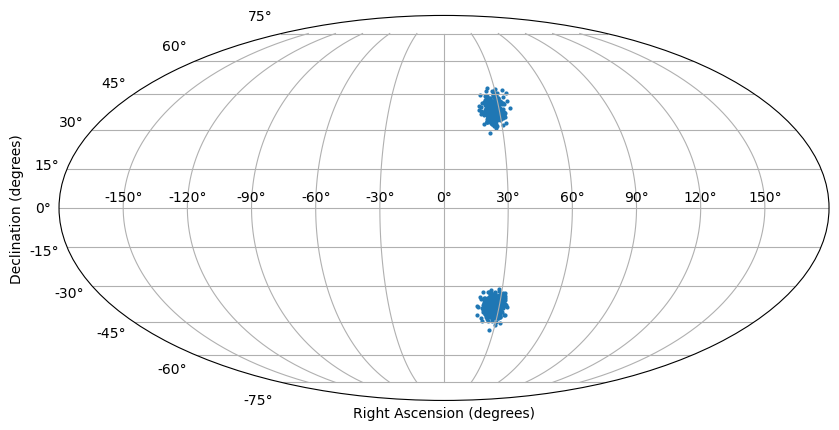

<Figure size 640x480 with 0 Axes>

In [83]:
def plot_mwd_radec(RA, Dec, name='skymap_1003.png', org=0):
    """
    Creates a Mollweide projection plot from RA and Dec samples.
    RA values should be in [0, 360), Dec in [-90, 90], in degrees.
    org sets the central longitude (e.g., 0 or 180 for the galactic center).
    """

    x_rad = RA
    Dec_rad = Dec

    fig = plt.figure(figsize=(10, 5))

    ax = fig.add_subplot(111, projection='mollweide')
    
    ax.scatter(x_rad, Dec_rad, s=4, alpha=1)

    ax.set_xlabel("Right Ascension (degrees)")
    ax.set_ylabel("Declination (degrees)")
    ax.grid(True)
    plt.show()
    plt.savefig(name)

plot_mwd_radec(ra_samples, dec_samples)


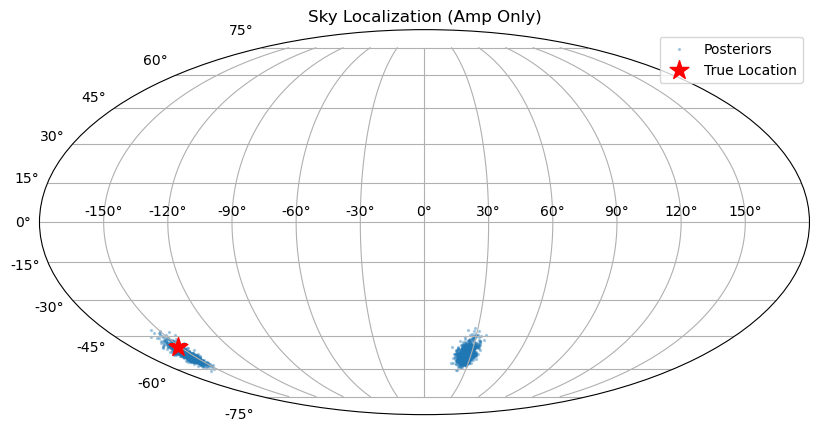

In [86]:
import matplotlib.pyplot as plt

def plot_mwd_radec_with_true(ra_samples, dec_samples, true_ra, true_dec):
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(111, projection='mollweide')

    # 1. Plot the "Blob" (Posterior Samples)
    # We shift RA to be [-pi, pi] for the Mollweide projection
    ra_shifted = ra_samples - np.pi
    ax.scatter(ra_shifted, dec_samples, s=2, alpha=0.3, label="Posteriors")

    # 2. Plot the "True" Location (Injection)
    true_ra_shifted = true_ra - np.pi
    ax.scatter(true_ra_shifted, true_dec, s=200, marker='*', color='red', zorder=10, label="True Location")

    ax.grid(True)
    ax.legend()
    plt.title("Sky Localization (Amp Only)")
    plt.show()

# Extract samples from the result object
ra_samples = result.posterior['ra']
dec_samples = result.posterior['dec'] - np.pi/2 # Convert 0..pi to -pi/2..pi/2 if needed by your prior

plot_mwd_radec_with_true(ra_samples, dec_samples, injection_parameters['ra'], injection_parameters['dec'] - np.pi/2)